In [1]:
!pip install scikit-fuzzy

  Using cached scikit-fuzzy-0.4.2.tar.gz (993 kB)
  Preparing metadata (setup.py): started
  Preparing metadata (setup.py): finished with status 'done'
  Created wheel for scikit-fuzzy: filename=scikit_fuzzy-0.4.2-py3-none-any.whl size=894084 sha256=6aab1d9c504228fe8d9809901d4741168ae8e03f09b30b7ef2a8988cc4f7180b
  Stored in directory: c:\users\jose.puerta\appdata\local\pip\cache\wheels\b1\67\d1\6c29aeb1cd2d36447ad5b0de027580b8894aff702a9b50041e
Successfully built scikit-fuzzy


In [ ]:
import numpy as np
import skfuzzy.control as ctrl
import skfuzzy as fuzz

# Sparse universe makes calculations faster, without sacrifice accuracy.
# Only the critical points are included here; making it higher resolution is
# unnecessary.
universe = np.linspace(-2, 2, 41)

# Create the three fuzzy variables - two inputs, one output
error = ctrl.Antecedent(universe, 'error')
delta = ctrl.Antecedent(universe, 'delta')
output = ctrl.Consequent(universe, 'output')

# Here we use the convenience `automf` to populate the fuzzy variables with
# terms. The optional kwarg `names=` lets us specify the names of our Terms.
names = ['nb', 'ns', 'ze', 'ps', 'pb']
error.automf(names=names)
delta.automf(names=names)
output.automf(names=names)

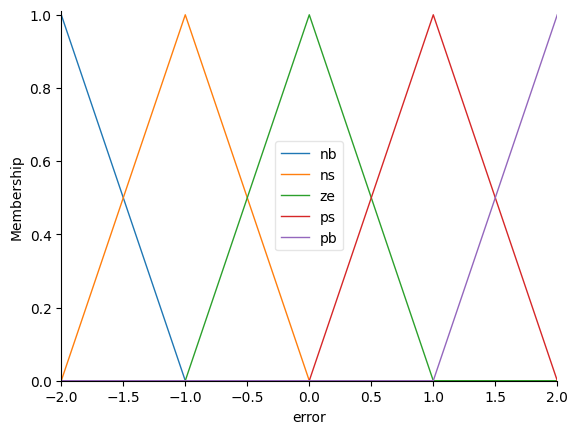

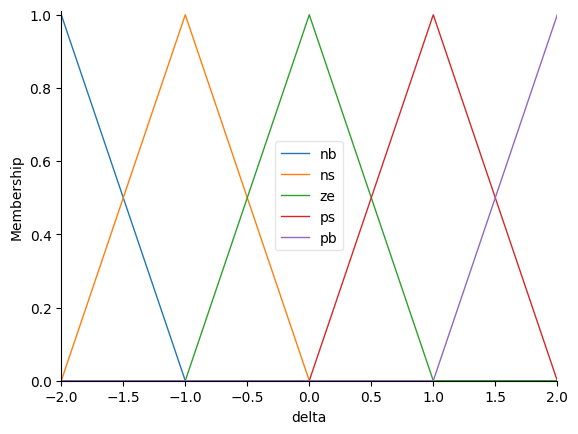

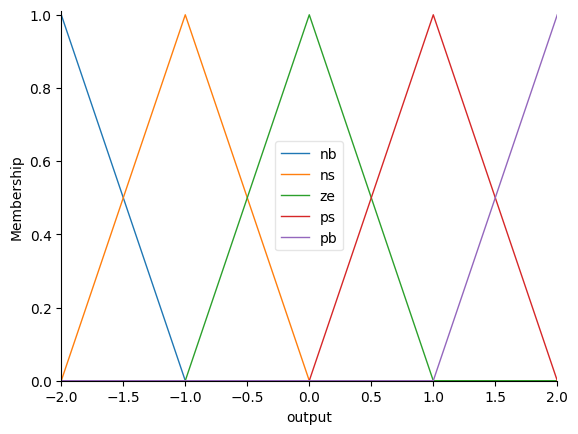

In [ ]:
error.view()
delta.view()
output.view()

In [ ]:
# Accediendo a la función de membresía para la etiqueta 'ze' (cero)
ze_membership_function = error['ze'].mf

# ze_membership_function ahora contiene los valores de la función de membresía para 'ze' en el universo definido
print("Función de pertenencia para 'ze':", ze_membership_function)

# Primero, necesitas el valor específico que quieres evaluar
valor = 0.725

grado_pertenencia = fuzz.interp_membership(universe,ze_membership_function,valor)

print(f"El grado de pertenencia de {valor} a 'ze' es: {grado_pertenencia}")


Función de pertenencia para 'ze': [0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.1 0.2 0.3 0.4 0.5 0.6 0.7
 0.8 0.9 1.  0.9 0.8 0.7 0.6 0.5 0.4 0.3 0.2 0.1 0.  0.  0.  0.  0.  0.
 0.  0.  0.  0.  0. ]
El grado de pertenencia de 0.725 a 'ze' es: 0.275


In [ ]:
rule0 = ctrl.Rule(antecedent=((error['nb'] & delta['nb']) |
                              (error['ns'] & delta['nb']) |
                              (error['nb'] & delta['ns'])),
                  consequent=output['nb'], label='rule nb')

rule1 = ctrl.Rule(antecedent=((error['nb'] & delta['ze']) |
                              (error['nb'] & delta['ps']) |
                              (error['ns'] & delta['ns']) |
                              (error['ns'] & delta['ze']) |
                              (error['ze'] & delta['ns']) |
                              (error['ze'] & delta['nb']) |
                              (error['ps'] & delta['nb'])),
                  consequent=output['ns'], label='rule ns')

rule2 = ctrl.Rule(antecedent=((error['nb'] & delta['pb']) |
                              (error['ns'] & delta['ps']) |
                              (error['ze'] & delta['ze']) |
                              (error['ps'] & delta['ns']) |
                              (error['pb'] & delta['nb'])),
                  consequent=output['ze'], label='rule ze')

rule3 = ctrl.Rule(antecedent=((error['ns'] & delta['pb']) |
                              (error['ze'] & delta['pb']) |
                              (error['ze'] & delta['ps']) |
                              (error['ps'] & delta['ps']) |
                              (error['ps'] & delta['ze']) |
                              (error['pb'] & delta['ze']) |
                              (error['pb'] & delta['ns'])),
                  consequent=output['ps'], label='rule ps')

rule4 = ctrl.Rule(antecedent=((error['ps'] & delta['pb']) |
                              (error['pb'] & delta['pb']) |
                              (error['pb'] & delta['ps'])),
                  consequent=output['pb'], label='rule pb')

In [ ]:
system = ctrl.ControlSystem(rules=[rule0, rule1, rule2, rule3, rule4])

# Later we intend to run this system with a 21*21 set of inputs, so we allow
# that many plus one unique runs before results are flushed.
# Subsequent runs would return in 1/8 the time!
sim = ctrl.ControlSystemSimulation(system, flush_after_run=21 * 21 + 1)

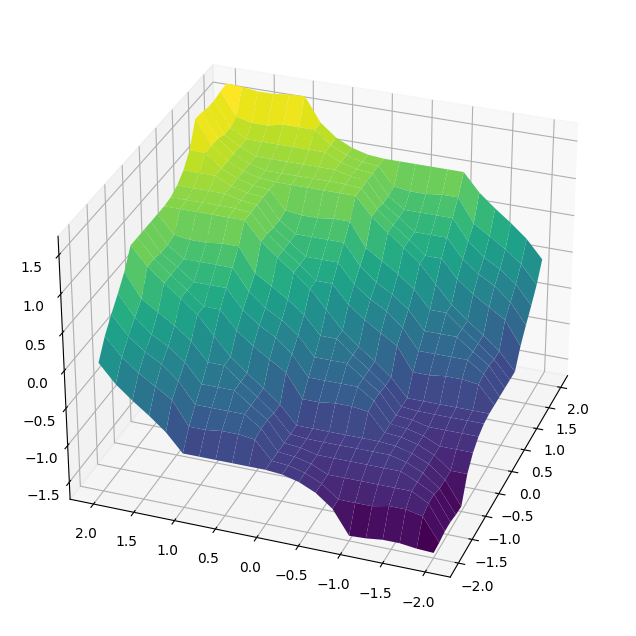

In [ ]:
# We can simulate at higher resolution with full accuracy
upsampled = np.linspace(-2, 2, 21)
x, y = np.meshgrid(upsampled, upsampled)
z = np.zeros_like(x)

# Loop through the system 21*21 times to collect the control surface
for i in range(21):
    for j in range(21):
        sim.input['error'] = x[i, j]
        sim.input['delta'] = y[i, j]
        sim.compute()
        z[i, j] = sim.output['output']

# Plot the result in pretty 3D with alpha blending
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # Required for 3D plotting

fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(111, projection='3d')

surf = ax.plot_surface(x, y, z, rstride=1, cstride=1, cmap='viridis',
                       linewidth=0.4, antialiased=True)

#cset = ax.contourf(x, y, z, zdir='z', offset=-2.5, cmap='viridis', alpha=0.5)
#cset = ax.contourf(x, y, z, zdir='x', offset=3, cmap='viridis', alpha=0.5)
#cset = ax.contourf(x, y, z, zdir='y', offset=3, cmap='viridis', alpha=0.5)

ax.view_init(30, 200)

In [ ]:
universe_1 = np.linspace(-20, 20, 41)
universe_2 = np.linspace(-50,50, 41)
universe_3 = np.linspace(-1,1,41)

print(universe_1.shape)
print(universe_2.shape)
print(universe_3.shape)

# Create the three fuzzy variables - two inputs, one output
delta_t = ctrl.Antecedent(universe_1, 'temperatura')
delta_h = ctrl.Antecedent(universe_2, 'humedad')
gas = ctrl.Consequent(universe_3, 'gas')
agua = ctrl.Consequent(universe_3, 'agua')

# Here we use the convenience `automf` to populate the fuzzy variables with
# terms. The optional kwarg `names=` lets us specify the names of our Terms.
names_1 = ['mb', 'b', 'c', 'a', 'ma']
names_2 = ['b','c','a']
names_3 = ['ca','cm','sc','am','aa']
delta_t.automf(names=names_1)
delta_h.automf(names=names_2)
gas.automf(names=names_3)
agua.automf(names=names_3)

(41,)
(41,)
(41,)


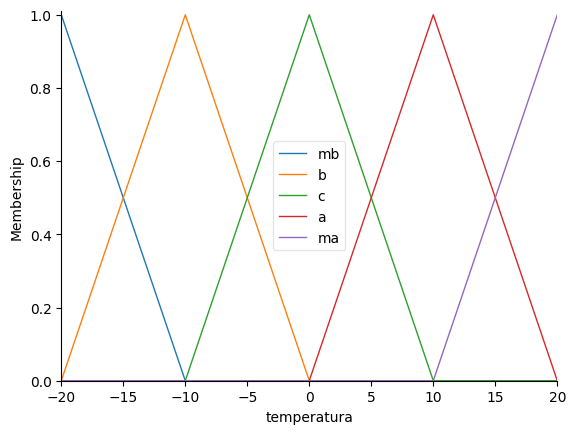

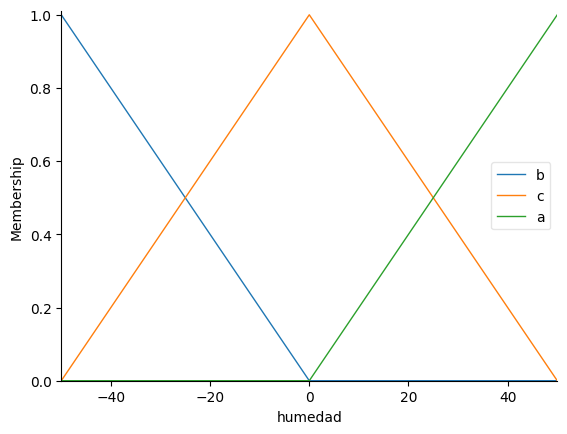

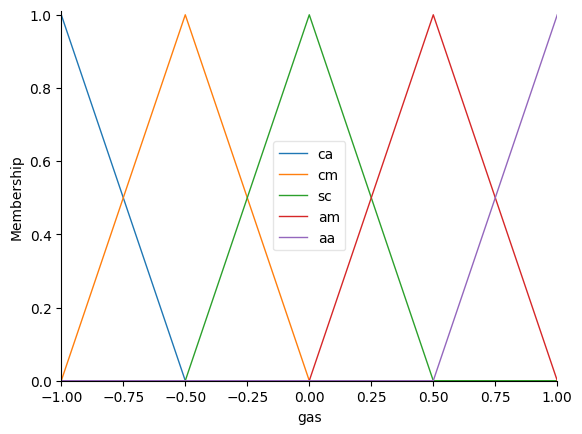

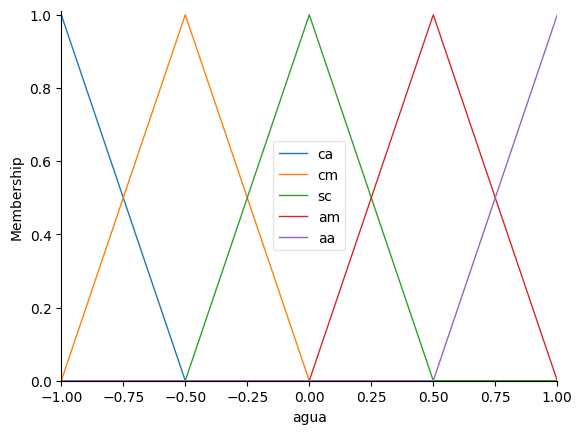

In [ ]:
delta_t.view()
delta_h.view()
gas.view()
agua.view()

In [ ]:
rule0 = ctrl.Rule(antecedent=(delta_t['mb'] & delta_h['b']),consequent=agua['aa'])
rule1 = ctrl.Rule(antecedent=(delta_t['mb'] & delta_h['c']),consequent=agua['sc'])
rule2 = ctrl.Rule(antecedent=(delta_t['mb'] & delta_h['a']),consequent=agua['ca'])
rule3 = ctrl.Rule(antecedent=(delta_t['b'] & delta_h['b']),consequent=agua['aa'])
rule4 = ctrl.Rule(antecedent=(delta_t['b'] & delta_h['c']),consequent=agua['sc'])
rule5 = ctrl.Rule(antecedent=(delta_t['b'] & delta_h['a']),consequent=agua['ca'])
rule6 = ctrl.Rule(antecedent=(delta_t['c'] & delta_h['b']),consequent=agua['am'])
rule7 = ctrl.Rule(antecedent=(delta_t['c'] & delta_h['c']),consequent=agua['sc'])
rule8 = ctrl.Rule(antecedent=(delta_t['c'] & delta_h['a']),consequent=agua['cm'])
rule9 = ctrl.Rule(antecedent=(delta_t['a'] & delta_h['b']),consequent=agua['sc'])
rule10 = ctrl.Rule(antecedent=(delta_t['a'] & delta_h['c']),consequent=agua['sc'])
rule11 = ctrl.Rule(antecedent=(delta_t['a'] & delta_h['a']),consequent=agua['sc'])
rule12 = ctrl.Rule(antecedent=(delta_t['ma'] & delta_h['b']),consequent=agua['sc'])
rule13 = ctrl.Rule(antecedent=(delta_t['ma'] & delta_h['c']),consequent=agua['am'])
rule14 = ctrl.Rule(antecedent=(delta_t['ma'] & delta_h['a']),consequent=agua['sc'])

In [ ]:
rule15 = ctrl.Rule(antecedent=(delta_t['mb'] & delta_h['b']),consequent=gas['aa'])
rule16 = ctrl.Rule(antecedent=(delta_t['mb'] & delta_h['c']),consequent=gas['aa'])
rule17 = ctrl.Rule(antecedent=(delta_t['mb'] & delta_h['a']),consequent=gas['am'])
rule18 = ctrl.Rule(antecedent=(delta_t['b'] & delta_h['b']),consequent=gas['aa'])
rule19 = ctrl.Rule(antecedent=(delta_t['b'] & delta_h['c']),consequent=gas['am'])
rule20 = ctrl.Rule(antecedent=(delta_t['b'] & delta_h['a']),consequent=gas['sc'])
rule21 = ctrl.Rule(antecedent=(delta_t['c'] & delta_h['b']),consequent=gas['sc'])
rule22 = ctrl.Rule(antecedent=(delta_t['c'] & delta_h['c']),consequent=gas['sc'])
rule23 = ctrl.Rule(antecedent=(delta_t['c'] & delta_h['a']),consequent=gas['sc'])
rule24 = ctrl.Rule(antecedent=(delta_t['a'] & delta_h['b']),consequent=gas['sc'])
rule25 = ctrl.Rule(antecedent=(delta_t['a'] & delta_h['c']),consequent=gas['am'])
rule26 = ctrl.Rule(antecedent=(delta_t['a'] & delta_h['a']),consequent=gas['am'])
rule27 = ctrl.Rule(antecedent=(delta_t['ma'] & delta_h['b']),consequent=gas['am'])
rule28 = ctrl.Rule(antecedent=(delta_t['ma'] & delta_h['c']),consequent=gas['am'])
rule29 = ctrl.Rule(antecedent=(delta_t['ma'] & delta_h['a']),consequent=gas['aa'])

In [ ]:
system = ctrl.ControlSystem(rules=[rule0, rule1, rule2, rule3, rule4,rule5, rule6, rule7, rule8, rule9,rule10, rule11, rule12, rule13, rule14,
                                  rule15, rule16, rule17, rule18, rule19,rule20, rule21, rule22, rule23, rule24,rule25, rule26, rule27, rule28, rule29])
sim = ctrl.ControlSystemSimulation(system)

In [ ]:
sim.input['temperatura'] = 10
sim.input['humedad'] = 30
sim.compute()
print(sim.output)

OrderedDict([('agua', -2.2716616947315327e-17), ('gas', 0.49999999999999994)])


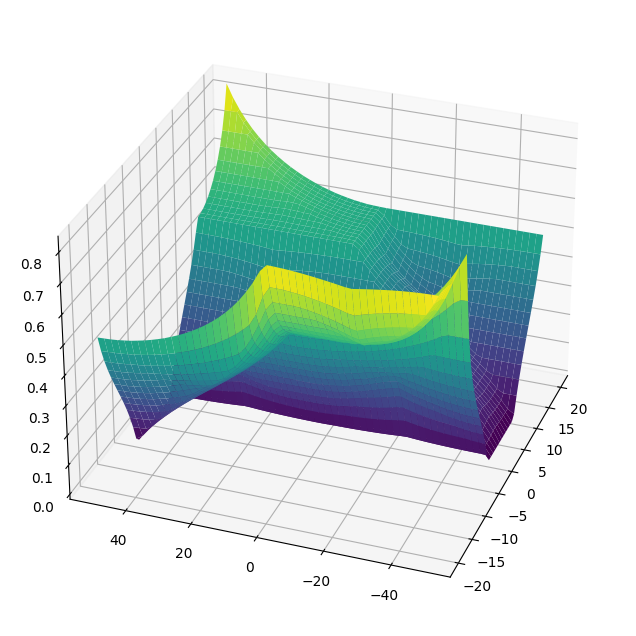

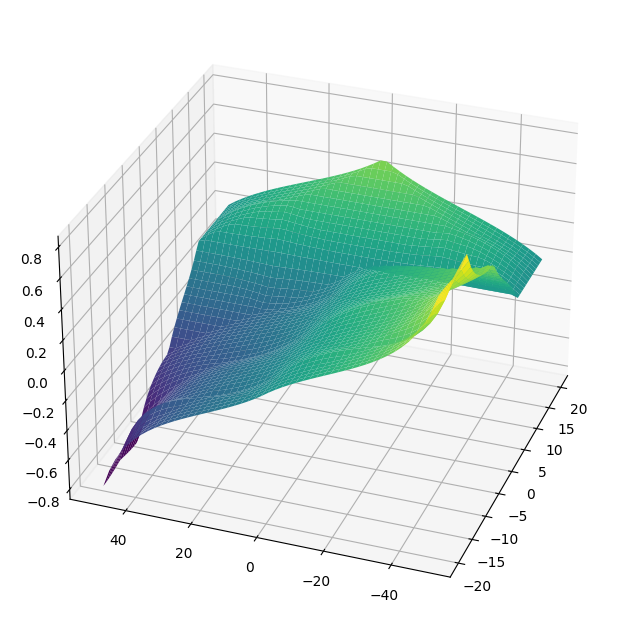

In [ ]:
upsampled_1 = np.linspace(-20, 20, 50)
upsampled_2 = np.linspace(-50,50, 50)
x, y = np.meshgrid(upsampled_1, upsampled_2)
z_gas = np.zeros_like(x)
z_agua = np.zeros_like(x)

for i in range(upsampled_1.shape[0]):
    for j in range(upsampled_2.shape[0]):
        sim.input['temperatura'] = x[i, j]
        sim.input['humedad'] = y[i, j]
        sim.compute()
        z_agua[i, j] = sim.output['agua']
        z_gas[i, j] = sim.output['gas']

# Plot the result in pretty 3D with alpha blending
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # Required for 3D plotting

fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(111, projection='3d')

surf = ax.plot_surface(x, y, z_gas, rstride=1, cstride=1, cmap='viridis',
                       linewidth=0.4, antialiased=True)

#cset = ax.contourf(x, y, z, zdir='z', offset=-2.5, cmap='viridis', alpha=0.5)
#cset = ax.contourf(x, y, z, zdir='x', offset=3, cmap='viridis', alpha=0.5)
#cset = ax.contourf(x, y, z, zdir='y', offset=3, cmap='viridis', alpha=0.5)

ax.view_init(30, 200)

fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(111, projection='3d')

surf = ax.plot_surface(x, y, z_agua, rstride=1, cstride=1, cmap='viridis',
                       linewidth=0.4, antialiased=True)

#cset = ax.contourf(x, y, z, zdir='z', offset=-2.5, cmap='viridis', alpha=0.5)
#cset = ax.contourf(x, y, z, zdir='x', offset=3, cmap='viridis', alpha=0.5)
#cset = ax.contourf(x, y, z, zdir='y', offset=3, cmap='viridis', alpha=0.5)

ax.view_init(30, 200)

In [ ]:
def environement(t,h,df,da):
    dt = t + (da*1.5)
    dt = dt + (df*2)
    dh = h + (da*2)
    dh = dh + (df*0.5)
    return dt, dh

In [ ]:
t_c = 10
t_r = 25
h_c = 15
h_r = 30

df = da = 0.4

t_n,h_n = environement(t_c,h_c,df,da)

In [ ]:
print(t_n,h_n)

11.4 16.0


In [ ]:
delta_t = t_n - t_r
delta_h = h_n - h_r

In [ ]:
print(delta_t,delta_h)

-13.6 -14.0
